In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [4]:
#know your data:
class EDAPipeline:
    '''A class to perform Exploratory Data Analysis (EDA) on a given dataset.'''

    def __init__(self, df: pd.DataFrame, target_col: str= None):
        self.df = df.copy()
        self.target_col = target_col
        self.numerical_cols = self.df.select_dtypes(include=np.number).columns.tolist()
        self.categorical_cols = self.df.select_dtypes(include='object').columns.tolist()

    def structural_audit(self):
        '''Performs a structural audit of the dataset, including shape, data types, and missing values.'''
        print("=== Structural Audit ===")
        print(f"Data shape: {self.df.shape[0]} rows, {self.df.shape[1]} columns")
        print('--- Data Types & Missing Values ---')
        print(self.df.info())
        print('/n')
        return self
    
    def quality_audit(self):
        '''performs a quality audit of the dataset, including summary statistics and missing value analysis.'''
        print("=== Quality Audit ===")
        missing_count = self.df.isnull().sum()
        missing_pct = 100 * missing_count / len(self.df)
        missing_table = pd.concat([missing_count, missing_pct], axis=1, keys=['Missing Count', 'Missing Percentage'])
        missing_table = missing_table[missing_table['Missing Count'] >0].sort_values('Missing Percentage', ascending=False)

        print("Missing Data Profile:")
        if missing_table.empty:
            print("No missing values found.")
        else:
            print(missing_table)

        duplicate_count = self.df.duplicated().sum()
        print(f"\nNumber of duplicate rows: {duplicate_count}")
        print('/n')
        return self
    
    def descriptive_stats(self):
        '''Provides descriptive statistics for numerical and categorical columns.'''
        print("=== Descriptive Statistics ===")
        if self.numerical_cols:
            print("\nNumerical Features Summary:")
            print(self.df[self.numerical_cols].describe().T)
        if self.categorical_cols:
            print("\nCategorical Features Summary:")
            print(self.df[self.categorical_cols].describe().T)
        print("\n")
        return self

    def plot_distributions(self):
        """Step 4: Univariate plots (Histograms for numeric, Bar plots for categorical)."""
        print("=== GENERATING UNIVARIATE VISUALIZATIONS ===")

        if self.numerical_cols:
            num_features = len(self.numerical_cols)
            fig, axes = plt.subplots(
                nrows=(num_features +1) // 2,
                ncols=2,
                figsize=(12, num_features * 2)
                )
            axes = axes.flatten()
            for i, col in enumerate(self.numerical_cols):
                sns.histplot(self.df[col], kde=True, ax=axes[i], color='teal')
                axes[i].set_title(f'Distribution of {col}', fontsize=10)
            # Hide unused axes
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()

        if self.categorical_cols:
            cat_features = len(self.categorical_cols)
            fig, axes = plt.subplots(nrows=(cat_features + 1) // 2, ncols=2, figsize=(12, cat_features * 2))
            axes = axes.flatten()
            for i, col in enumerate(self.categorical_cols):
                # Target high cardinality values safely by truncating to top 10
                top_cats = self.df[col].value_counts().head(10)
                sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[i], palette='viridis')
                axes[i].set_title(f'Top Categories: {col}', fontsize=10)
            for j in range(i + 1, len(axes)):
                fig.delaxes(axes[j])
            plt.tight_layout()
            plt.show()
        return self
    
    def plot_correlations(self):
        """Step 5: Multivariate analysis isolating numeric linear relationships."""
        if len(self.numerical_cols) > 1:
            print("=== GENERATING CORRELATION MATRIX ===")
            plt.figure(figsize=(10, 8))
            corr_matrix = self.df[self.numerical_cols].corr()
            mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
            sns.heatmap(
                corr_matrix, 
                mask=mask, 
                annot=True, 
                fmt=".2f", 
                cmap='coolwarm', 
                center=0,
                square=True)
            plt.title("Numerical Correlation Matrix (Upper Triangle Masked)")
            plt.show()
        return self
    
    def run_all(self):
        """Execute the entire pipeline workflow sequentially."""
        return (self.structural_audit()
                    .quality_audit()
                    .descriptive_stats()
                    .plot_distributions()
                    .plot_correlations())

In [5]:
data = pd.DataFrame({
    'Age': [25, 30, 47, 35, np.nan, 28, 52, 39, 41, 30],
    'Salary': [50000, 62000, 110000, 75000, 58000, 52000, np.nan, 82000, 91000, 62000],
    'Department': ['IT', 'HR', 'Exec', 'IT', 'Sales', 'HR', 'IT', 'Sales', 'Exec', 'HR'],
    'Remote': ['Yes', 'No', 'No', 'Yes', 'Yes', 'No', 'Yes', 'No', 'No', 'No']
})

=== Structural Audit ===
Data shape: 10 rows, 4 columns
--- Data Types & Missing Values ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10 entries, 0 to 9
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Age         9 non-null      float64
 1   Salary      9 non-null      float64
 2   Department  10 non-null     object 
 3   Remote      10 non-null     object 
dtypes: float64(2), object(2)
memory usage: 452.0+ bytes
None
/n
=== Quality Audit ===
Missing Data Profile:
        Missing Count  Missing Percentage
Age                 1                10.0
Salary              1                10.0

Number of duplicate rows: 1
/n
=== Descriptive Statistics ===

Numerical Features Summary:
        count          mean           std      min      25%      50%      75%  \
Age       9.0     36.333333      9.137833     25.0     30.0     35.0     41.0   
Salary    9.0  71333.333333  19968.725548  50000.0  58000.0  62000.0  82

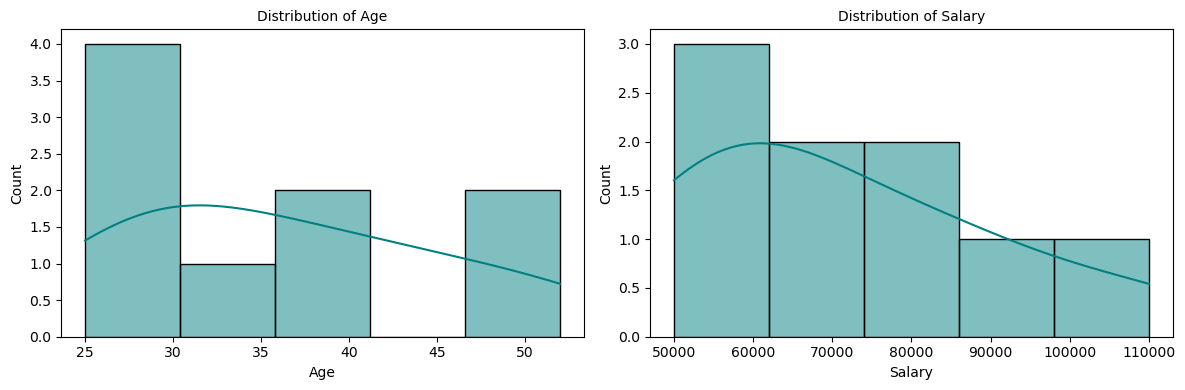

/var/folders/23/m7plmfj94kb8p9ghd1v3b9lh0000gn/T/ipykernel_50817/3741889017.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[i], palette='viridis')
/var/folders/23/m7plmfj94kb8p9ghd1v3b9lh0000gn/T/ipykernel_50817/3741889017.py:79: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_cats.values, y=top_cats.index, ax=axes[i], palette='viridis')


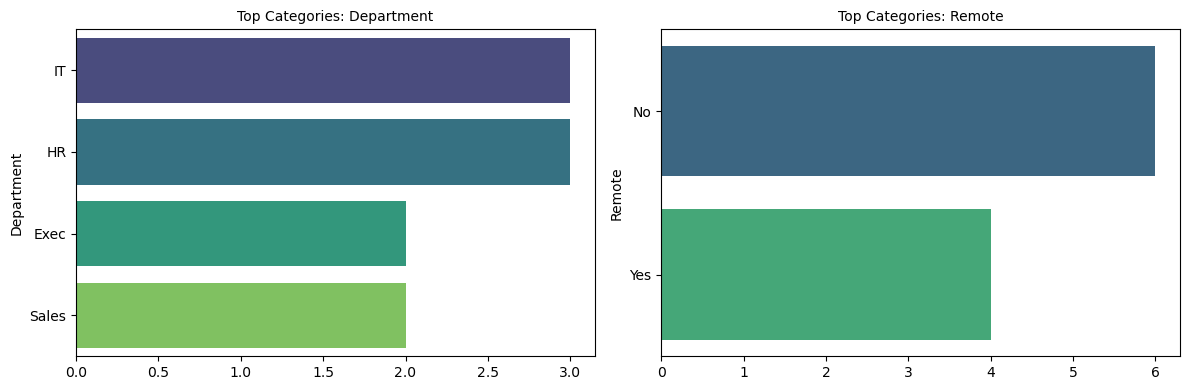

=== GENERATING CORRELATION MATRIX ===


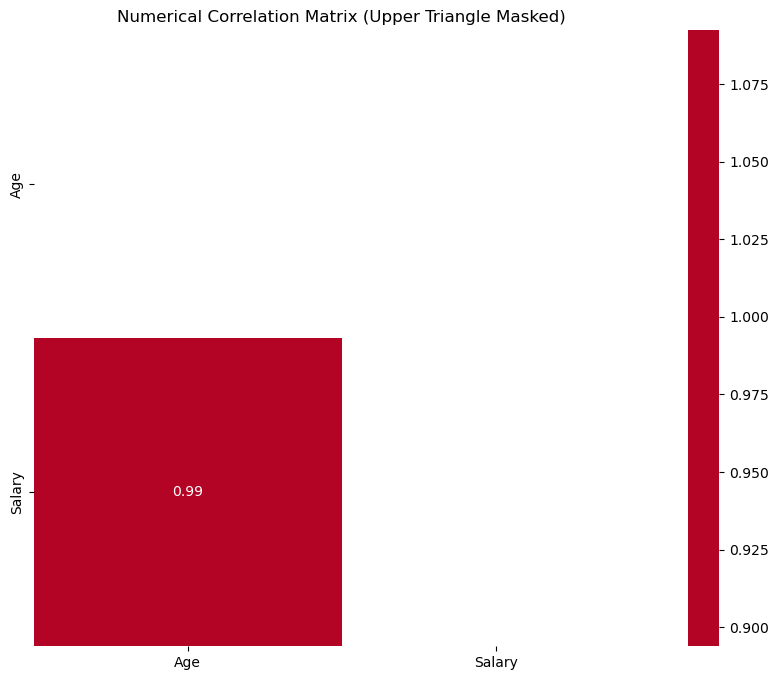

In [6]:
pipeline = EDAPipeline(df=data)
pipeline.run_all()